# 🤖 Fake Social Media Account Detection System
### Final Year Project — Shah Khalid & Ziad Muhammad
---
**Platforms Covered:** Twitter | Instagram | Facebook | LinkedIn

**Model Used:** Random Forest Classifier

**Goal:** Detect fake/bot accounts across multiple social media platforms

---
## Table of Contents
1. Install and Import Libraries
2. Generate Twitter Dataset
3. Generate Facebook and LinkedIn Datasets
4. Preprocess and Combine All Datasets
5. Exploratory Data Analysis (EDA)
6. Feature Engineering
7. Train Machine Learning Models
8. Evaluate Model Performance
9. Predict on New Data

---
## Step 1: Install and Import Libraries

In [19]:
# Run this cell first to install required libraries
%pip install pandas numpy scikit-learn joblib matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

# Set random seed for reproducibility
np.random.seed(42)

# Create required folders
os.makedirs('dataset', exist_ok=True)
os.makedirs('model', exist_ok=True)

print('All libraries imported successfully!')
print('Folders created: dataset/ and model/')

All libraries imported successfully!
Folders created: dataset/ and model/


---
## Step 2: Generate Twitter Dataset
This generates a realistic synthetic Twitter dataset with 25,000 real and 25,000 fake accounts

In [3]:
# fix_twitter.py — Generate synthetic Twitter dataset

np.random.seed(42)
n_real = 25000
n_fake = 25000

print('Generating realistic Twitter dataset...')

# Real accounts: high followers, often verified, longer bios, have location
real = {
    'followers_count': np.random.randint(500, 50000, n_real),
    'verified':        np.random.choice([0, 1], n_real, p=[0.7, 0.3]),
    'retweet_count':   np.random.randint(50, 5000, n_real),
    'mention_count':   np.random.randint(20, 2000, n_real),
    'bio_length':      np.random.randint(80, 500, n_real),
    'has_location':    np.random.choice([0, 1], n_real, p=[0.2, 0.8]),
    'label':           np.zeros(n_real, dtype=int)   # 0 = REAL
}

# Fake/bot accounts: very low followers, not verified, short or no bio
fake = {
    'followers_count': np.random.randint(0, 200, n_fake),
    'verified':        np.zeros(n_fake, dtype=int),
    'retweet_count':   np.random.randint(0, 30, n_fake),
    'mention_count':   np.random.randint(0, 20, n_fake),
    'bio_length':      np.random.randint(0, 40, n_fake),
    'has_location':    np.random.choice([0, 1], n_fake, p=[0.8, 0.2]),
    'label':           np.ones(n_fake, dtype=int)    # 1 = FAKE
}

df_real    = pd.DataFrame(real)
df_fake    = pd.DataFrame(fake)
twitter_df = pd.concat([df_real, df_fake], ignore_index=True)
twitter_df = twitter_df.sample(frac=1).reset_index(drop=True)  # Shuffle rows
twitter_df['platform'] = 'twitter'

twitter_df.to_csv('dataset/twitter_clean.csv', index=False)

print(f'Twitter dataset created: {twitter_df.shape}')
print(f'Real accounts : {(twitter_df["label"]==0).sum()}')
print(f'Fake accounts : {(twitter_df["label"]==1).sum()}')
twitter_df.head()

Generating realistic Twitter dataset...
Twitter dataset created: (50000, 8)
Real accounts : 25000
Fake accounts : 25000


,followers_count,verified,retweet_count,mention_count,bio_length,has_location,label,platform
0,40382,0,1919,1330,192,0,0,twitter
1,3292,0,2465,186,273,1,0,twitter
2,68,0,1,3,33,0,1,twitter
3,19095,0,3884,1832,343,1,0,twitter
4,34993,1,2950,1714,483,1,0,twitter


---
## Step 3: Generate Facebook and LinkedIn Datasets
This generates synthetic datasets for Facebook and LinkedIn platforms

In [4]:
# generate_dataset.py — Generate Facebook dataset

np.random.seed(42)
n_real = 1000
n_fake = 1000

def generate_facebook_data():
    real = {
        'username':         ['user_' + str(i) for i in range(n_real)],
        'friends_count':    np.random.randint(100, 2000, n_real),
        'followers_count':  np.random.randint(50, 3000, n_real),
        'posts_count':      np.random.randint(20, 500, n_real),
        'profile_pic':      np.ones(n_real, dtype=int),
        'bio_length':       np.random.randint(50, 300, n_real),
        'account_age_days': np.random.randint(365, 3000, n_real),
        'groups_joined':    np.random.randint(5, 50, n_real),
        'verified':         np.random.choice([0, 1], n_real, p=[0.8, 0.2]),
        'label':            np.zeros(n_real, dtype=int)
    }
    fake = {
        'username':         ['fake_' + str(i) for i in range(n_fake)],
        'friends_count':    np.random.randint(0, 100, n_fake),
        'followers_count':  np.random.randint(0, 50, n_fake),
        'posts_count':      np.random.randint(0, 20, n_fake),
        'profile_pic':      np.random.choice([0, 1], n_fake, p=[0.6, 0.4]),
        'bio_length':       np.random.randint(0, 50, n_fake),
        'account_age_days': np.random.randint(1, 180, n_fake),
        'groups_joined':    np.random.randint(0, 5, n_fake),
        'verified':         np.zeros(n_fake, dtype=int),
        'label':            np.ones(n_fake, dtype=int)
    }
    df = pd.concat([pd.DataFrame(real), pd.DataFrame(fake)], ignore_index=True)
    return df.sample(frac=1).reset_index(drop=True)

facebook_df = generate_facebook_data()
facebook_df.to_csv('dataset/facebook.csv', index=False)
print(f'Facebook dataset created: {facebook_df.shape}')
print(f'Real: {(facebook_df["label"]==0).sum()} | Fake: {(facebook_df["label"]==1).sum()}')
facebook_df.head()

Facebook dataset created: (2000, 10)
Real: 1000 | Fake: 1000


,username,friends_count,followers_count,posts_count,profile_pic,bio_length,account_age_days,groups_joined,verified,label
0,user_326,1634,552,386,1,196,2132,10,1,0
1,user_283,1859,285,443,1,187,2411,49,0,0
2,fake_84,61,38,13,0,49,23,2,0,1
3,fake_963,57,26,8,1,11,128,4,0,1
4,user_632,531,2761,138,1,57,2255,27,0,0


In [5]:
# generate_dataset.py — Generate LinkedIn dataset

def generate_linkedin_data():
    real = {
        'username':           ['professional_' + str(i) for i in range(n_real)],
        'connections_count':  np.random.randint(100, 2000, n_real),
        'followers_count':    np.random.randint(50, 5000, n_real),
        'posts_count':        np.random.randint(10, 200, n_real),
        'profile_pic':        np.ones(n_real, dtype=int),
        'bio_length':         np.random.randint(100, 500, n_real),
        'account_age_days':   np.random.randint(365, 4000, n_real),
        'skills_count':       np.random.randint(5, 50, n_real),
        'verified':           np.random.choice([0, 1], n_real, p=[0.7, 0.3]),
        'label':              np.zeros(n_real, dtype=int)
    }
    fake = {
        'username':           ['fake_pro_' + str(i) for i in range(n_fake)],
        'connections_count':  np.random.randint(0, 50, n_fake),
        'followers_count':    np.random.randint(0, 30, n_fake),
        'posts_count':        np.random.randint(0, 10, n_fake),
        'profile_pic':        np.random.choice([0, 1], n_fake, p=[0.5, 0.5]),
        'bio_length':         np.random.randint(0, 80, n_fake),
        'account_age_days':   np.random.randint(1, 90, n_fake),
        'skills_count':       np.random.randint(0, 5, n_fake),
        'verified':           np.zeros(n_fake, dtype=int),
        'label':              np.ones(n_fake, dtype=int)
    }
    df = pd.concat([pd.DataFrame(real), pd.DataFrame(fake)], ignore_index=True)
    return df.sample(frac=1).reset_index(drop=True)

linkedin_df = generate_linkedin_data()
linkedin_df.to_csv('dataset/linkedin.csv', index=False)
print(f'LinkedIn dataset created: {linkedin_df.shape}')
print(f'Real: {(linkedin_df["label"]==0).sum()} | Fake: {(linkedin_df["label"]==1).sum()}')
linkedin_df.head()

LinkedIn dataset created: (2000, 10)
Real: 1000 | Fake: 1000


,username,connections_count,followers_count,posts_count,profile_pic,bio_length,account_age_days,skills_count,verified,label
0,professional_865,669,4506,48,1,196,1720,8,1,0
1,professional_788,669,2489,14,1,149,3801,9,1,0
2,professional_365,1931,2171,187,1,187,1723,30,1,0
3,fake_pro_662,40,29,3,1,65,34,4,0,1
4,professional_477,1453,3460,189,1,225,3487,26,0,0


---
## Step 4: Preprocess and Combine All Datasets
Cleans each platform's data and combines into one unified dataset with same columns

In [6]:
# preprocess.py — Standardize all platform data and merge

print('Starting preprocessing...\n')

# ─── 1. TWITTER ───
print('--- Processing Twitter ---')
twitter_clean = pd.read_csv('dataset/twitter_clean.csv')
print(f'Twitter shape: {twitter_clean.shape}')
print(f'Fake: {(twitter_clean["label"]==1).sum()} | Real: {(twitter_clean["label"]==0).sum()}')

# ─── 2. INSTAGRAM (optional — only if files exist) ───
print('\n--- Processing Instagram ---')
instagram_clean = None
if os.path.exists('dataset/fusers.csv') and os.path.exists('dataset/users.csv'):
    fusers = pd.read_csv('dataset/fusers.csv')
    users  = pd.read_csv('dataset/users.csv')
    fusers['label'] = 1  # fake
    users['label']  = 0  # real
    instagram = pd.concat([fusers, users], ignore_index=True)
    instagram_clean = pd.DataFrame()
    instagram_clean['followers_count'] = pd.to_numeric(instagram['followers_count'], errors='coerce').fillna(0)
    instagram_clean['verified']        = pd.to_numeric(instagram['verified'], errors='coerce').fillna(0)
    instagram_clean['retweet_count']   = pd.to_numeric(instagram['statuses_count'], errors='coerce').fillna(0)
    instagram_clean['mention_count']   = pd.to_numeric(instagram['friends_count'], errors='coerce').fillna(0)
    instagram_clean['bio_length']      = instagram['description'].fillna('').apply(len)
    instagram_clean['has_location']    = instagram['location'].apply(lambda x: 0 if pd.isna(x) or str(x).strip()=='' else 1)
    instagram_clean['label']           = instagram['label']
    instagram_clean['platform']        = 'instagram'
    print(f'Instagram shape: {instagram_clean.shape}')
else:
    print('Instagram files not found — SKIPPING (add fusers.csv and users.csv to dataset/ folder)')

# ─── 3. FACEBOOK ───
print('\n--- Processing Facebook ---')
facebook = pd.read_csv('dataset/facebook.csv')
facebook_clean = pd.DataFrame()
facebook_clean['followers_count'] = facebook['followers_count']
facebook_clean['verified']        = facebook['verified']
facebook_clean['retweet_count']   = facebook['posts_count']
facebook_clean['mention_count']   = facebook['friends_count']
facebook_clean['bio_length']      = facebook['bio_length']
facebook_clean['has_location']    = np.ones(len(facebook), dtype=int)
facebook_clean['label']           = facebook['label']
facebook_clean['platform']        = 'facebook'
print(f'Facebook shape: {facebook_clean.shape}')

# ─── 4. LINKEDIN ───
print('\n--- Processing LinkedIn ---')
linkedin = pd.read_csv('dataset/linkedin.csv')
linkedin_clean = pd.DataFrame()
linkedin_clean['followers_count'] = linkedin['followers_count']
linkedin_clean['verified']        = linkedin['verified']
linkedin_clean['retweet_count']   = linkedin['posts_count']
linkedin_clean['mention_count']   = linkedin['connections_count']
linkedin_clean['bio_length']      = linkedin['bio_length']
linkedin_clean['has_location']    = np.ones(len(linkedin), dtype=int)
linkedin_clean['label']           = linkedin['label']
linkedin_clean['platform']        = 'linkedin'
print(f'LinkedIn shape: {linkedin_clean.shape}')

# ─── 5. MERGE ALL ───
print('\n--- Merging All Datasets ---')
dfs_to_merge = [twitter_clean, facebook_clean, linkedin_clean]
if instagram_clean is not None:
    dfs_to_merge.insert(1, instagram_clean)

combined = pd.concat(dfs_to_merge, ignore_index=True)
combined.dropna(inplace=True)
combined.reset_index(drop=True, inplace=True)
combined.to_csv('dataset/combined_data.csv', index=False)

print(f'\nFinal combined dataset shape: {combined.shape}')
print(f'Total Fake accounts : {(combined["label"]==1).sum()}')
print(f'Total Real accounts : {(combined["label"]==0).sum()}')
print(f'\nPlatform breakdown:')
print(combined['platform'].value_counts())
print('\nSaved to dataset/combined_data.csv')
combined.head(10)

Starting preprocessing...

--- Processing Twitter ---
Twitter shape: (50000, 8)
Fake: 25000 | Real: 25000

--- Processing Instagram ---
Instagram shape: (2818, 8)

--- Processing Facebook ---
Facebook shape: (2000, 8)

--- Processing LinkedIn ---
LinkedIn shape: (2000, 8)

--- Merging All Datasets ---

Final combined dataset shape: (56818, 8)
Total Fake accounts : 28337
Total Real accounts : 28481

Platform breakdown:
platform
twitter      50000
instagram     2818
facebook      2000
linkedin      2000
Name: count, dtype: int64

Saved to dataset/combined_data.csv


,followers_count,verified,retweet_count,mention_count,bio_length,has_location,label,platform
0,40382,0.0,1919,1330,192,0,0,twitter
1,3292,0.0,2465,186,273,1,0,twitter
2,68,0.0,1,3,33,0,1,twitter
3,19095,0.0,3884,1832,343,1,0,twitter
4,34993,1.0,2950,1714,483,1,0,twitter
5,99,0.0,3,9,1,0,1,twitter
6,195,0.0,29,9,14,0,1,twitter
7,173,0.0,27,7,3,0,1,twitter
8,23141,0.0,2921,1542,425,1,0,twitter
9,14944,1.0,1174,1322,278,1,0,twitter


---
## Step 5: Exploratory Data Analysis (EDA)
Visualize the data to understand patterns between fake and real accounts

In [7]:
# Load the combined dataset
df = pd.read_csv('dataset/combined_data.csv')

print('=== DATASET OVERVIEW ===')
print(f'Total records  : {len(df)}')
print(f'Total columns  : {df.shape[1]}')
print(f'Real accounts  : {(df["label"]==0).sum()}')
print(f'Fake accounts  : {(df["label"]==1).sum()}')
print(f'\nMissing values:\n{df.isnull().sum()}')
print()
df.describe()

=== DATASET OVERVIEW ===
Total records  : 56818
Total columns  : 8
Real accounts  : 28481
Fake accounts  : 28337

Missing values:
followers_count    0
verified           0
retweet_count      0
mention_count      0
bio_length         0
has_location       0
label              0
platform           0
dtype: int64



,followers_count,verified,retweet_count,mention_count,bio_length,has_location,label
count,56818.000000,56818.000000,56818.000000,56818.000000,56818.000000,56818.000000,56818.000000
mean,11173.080591,0.140008,1206.193108,506.225210,148.612799,0.551234,0.498733
std,15648.119874,0.346999,1891.919799,634.608965,154.959587,0.497373,0.500003
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,81.000000,0.000000,14.000000,11.000000,20.000000,0.000000,0.000000
50%,191.000000,0.000000,54.000000,97.000000,71.000000,1.000000,0.000000
75%,21673.750000,0.000000,2266.000000,968.000000,270.000000,1.000000,1.000000
max,408372.000000,1.000000,79876.000000,12773.000000,499.000000,1.000000,1.000000


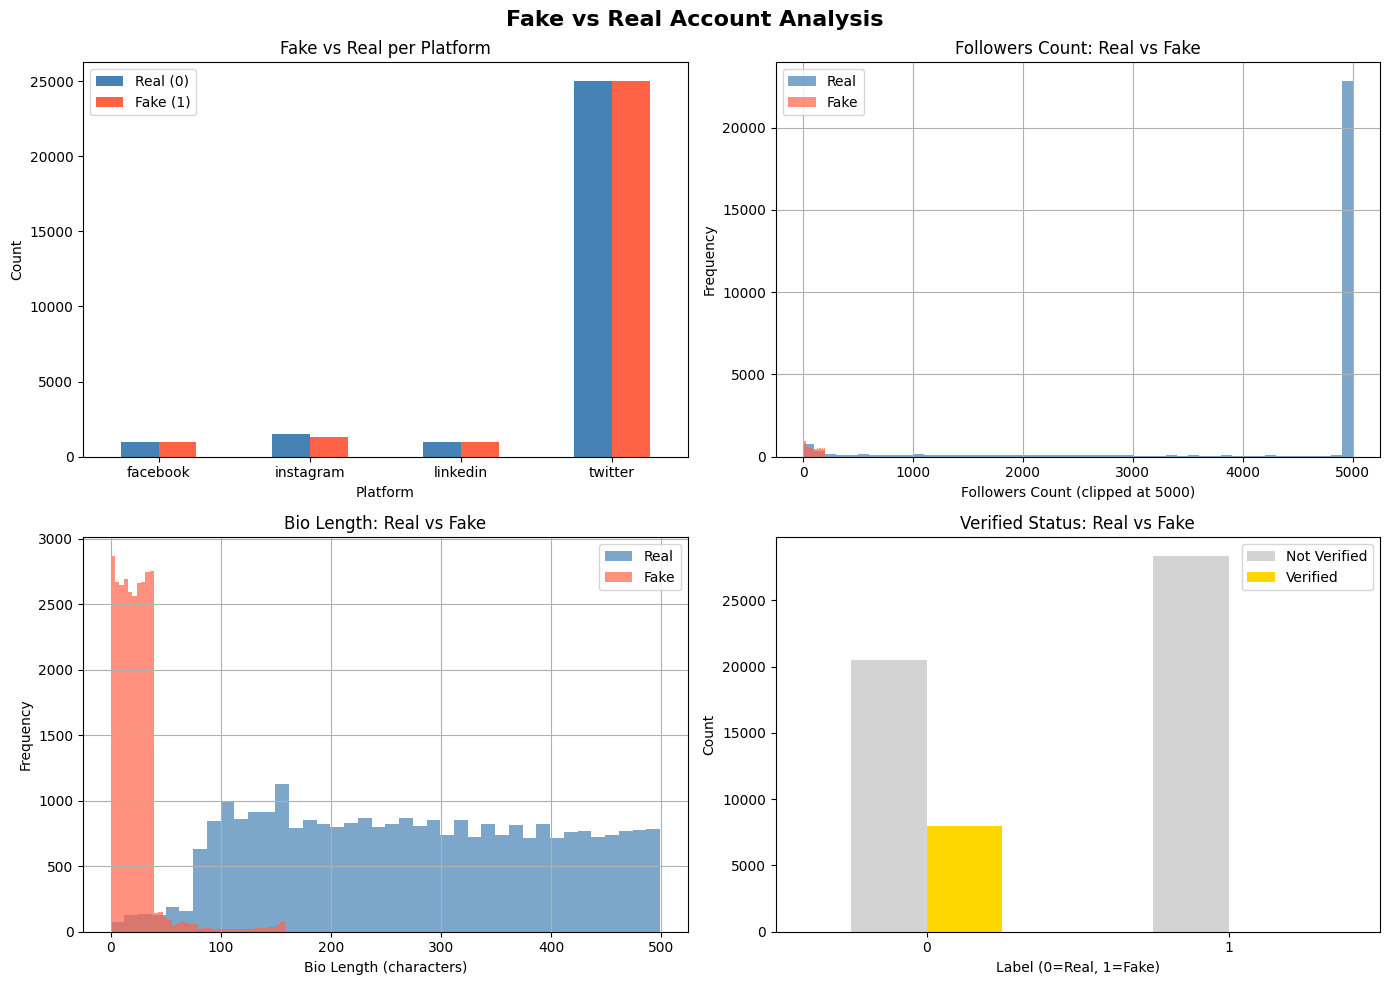

EDA chart saved to dataset/eda_analysis.png


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Fake vs Real Account Analysis', fontsize=16, fontweight='bold')

# Chart 1: Platform distribution
ax1 = axes[0, 0]
platform_counts = df.groupby(['platform', 'label']).size().unstack()
platform_counts.plot(kind='bar', ax=ax1, color=['steelblue', 'tomato'])
ax1.set_title('Fake vs Real per Platform')
ax1.set_xlabel('Platform')
ax1.set_ylabel('Count')
ax1.legend(['Real (0)', 'Fake (1)'])
ax1.tick_params(axis='x', rotation=0)

# Chart 2: Followers count
ax2 = axes[0, 1]
df[df['label']==0]['followers_count'].clip(0, 5000).hist(ax=ax2, bins=50, alpha=0.7, color='steelblue', label='Real')
df[df['label']==1]['followers_count'].clip(0, 5000).hist(ax=ax2, bins=50, alpha=0.7, color='tomato', label='Fake')
ax2.set_title('Followers Count: Real vs Fake')
ax2.set_xlabel('Followers Count (clipped at 5000)')
ax2.set_ylabel('Frequency')
ax2.legend()

# Chart 3: Bio length
ax3 = axes[1, 0]
df[df['label']==0]['bio_length'].hist(ax=ax3, bins=40, alpha=0.7, color='steelblue', label='Real')
df[df['label']==1]['bio_length'].hist(ax=ax3, bins=40, alpha=0.7, color='tomato', label='Fake')
ax3.set_title('Bio Length: Real vs Fake')
ax3.set_xlabel('Bio Length (characters)')
ax3.set_ylabel('Frequency')
ax3.legend()

# Chart 4: Verified status
ax4 = axes[1, 1]
verified_counts = df.groupby(['label', 'verified']).size().unstack(fill_value=0)
verified_counts.plot(kind='bar', ax=ax4, color=['lightgray', 'gold'])
ax4.set_title('Verified Status: Real vs Fake')
ax4.set_xlabel('Label (0=Real, 1=Fake)')
ax4.set_ylabel('Count')
ax4.legend(['Not Verified', 'Verified'])
ax4.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('dataset/eda_analysis.png', dpi=150)
plt.show()
print('EDA chart saved to dataset/eda_analysis.png')

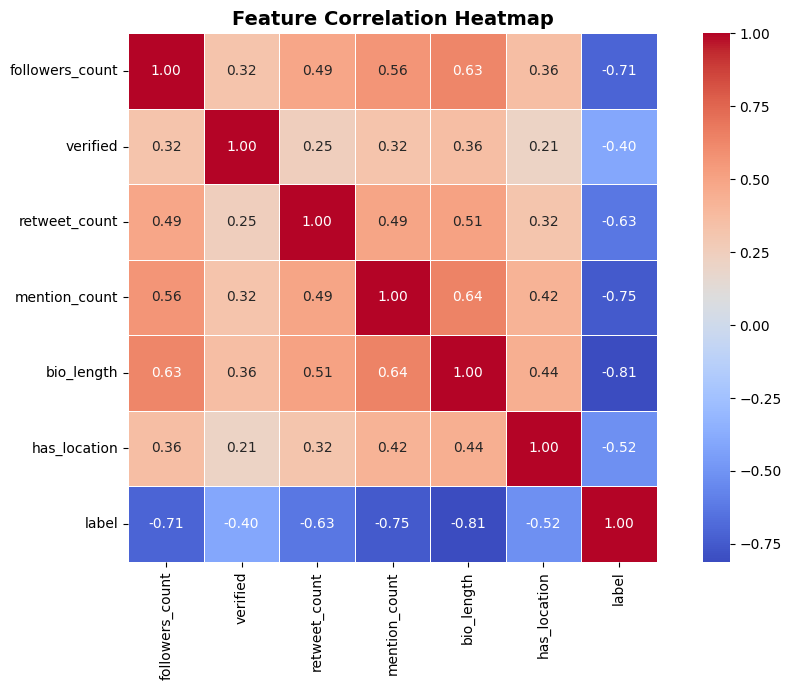

In [9]:
# Correlation Heatmap
plt.figure(figsize=(10, 7))
numeric_cols = ['followers_count', 'verified', 'retweet_count',
                'mention_count', 'bio_length', 'has_location', 'label']
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Step 6: Feature Engineering
Create extra features to improve model accuracy

In [10]:
df = pd.read_csv('dataset/combined_data.csv')

# Cap extreme values to reduce outlier effect
df['followers_count'] = df['followers_count'].clip(0, 10000)
df['retweet_count']   = df['retweet_count'].clip(0, 1000)
df['mention_count']   = df['mention_count'].clip(0, 1000)
df['bio_length']      = df['bio_length'].clip(0, 500)

# New engineered features
# follower_ratio: fake accounts often have very high or very low follower ratio
df['follower_ratio']  = df['followers_count'] / (df['mention_count'] + 1)
# activity_score: bots often retweet too much relative to followers
df['activity_score']  = df['retweet_count'] / (df['followers_count'] + 1)
# profile_score: how complete is the profile (verified + location + bio)
df['profile_score']   = df['verified'] + df['has_location'] + (df['bio_length'] > 0).astype(int)

print('New features created:')
print('  follower_ratio = followers / (mentions + 1)')
print('  activity_score = retweets / (followers + 1)')
print('  profile_score  = verified + has_location + bio_exists')
print(f'\nDataset shape after feature engineering: {df.shape}')
df[['followers_count', 'follower_ratio', 'activity_score', 'profile_score', 'label']].head(8)

New features created:
  follower_ratio = followers / (mentions + 1)
  activity_score = retweets / (followers + 1)
  profile_score  = verified + has_location + bio_exists

Dataset shape after feature engineering: (56818, 11)


,followers_count,follower_ratio,activity_score,profile_score,label
0,10000,9.990010,0.099990,1.0,0
1,3292,17.604278,0.303674,2.0,0
2,68,17.000000,0.014493,1.0,1
3,10000,9.990010,0.099990,2.0,0
4,10000,9.990010,0.099990,3.0,0
5,99,9.900000,0.030000,1.0,1
6,195,19.500000,0.147959,1.0,1
7,173,21.625000,0.155172,1.0,1


---
## Step 7: Train Machine Learning Models
Trains a separate Random Forest model for each platform, then one combined model

In [11]:
# train_model.py — Train Random Forest for each platform

features = [
    'followers_count', 'verified', 'retweet_count',
    'mention_count', 'bio_length', 'has_location',
    'follower_ratio', 'activity_score', 'profile_score'
]

platforms = df['platform'].unique().tolist()
results   = {}

print('=' * 55)
print('  TRAINING SEPARATE MODEL FOR EACH PLATFORM')
print('=' * 55)

for platform in platforms:
    print(f'\n--- Training {platform.upper()} model ---')

    pdf = df[df['platform'] == platform].copy()
    X   = pdf[features]
    y   = pdf['label']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    scaler    = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s  = scaler.transform(X_test)

    model = RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train_s, y_train)

    y_pred = model.predict(X_test_s)
    acc    = accuracy_score(y_test, y_pred)  * 100
    prec   = precision_score(y_test, y_pred) * 100
    rec    = recall_score(y_test, y_pred)    * 100
    f1     = f1_score(y_test, y_pred)        * 100

    print(f'   Accuracy  : {acc:.2f}%')
    print(f'   Precision : {prec:.2f}%')
    print(f'   Recall    : {rec:.2f}%')
    print(f'   F1 Score  : {f1:.2f}%')

    joblib.dump(model,  f'model/{platform}_model.pkl')
    joblib.dump(scaler, f'model/{platform}_scaler.pkl')

    results[platform] = {
        'accuracy': acc, 'precision': prec,
        'recall': rec, 'f1': f1,
        'y_test': y_test, 'y_pred': y_pred
    }

print('\nAll platform models trained and saved!')

  TRAINING SEPARATE MODEL FOR EACH PLATFORM

--- Training TWITTER model ---
   Accuracy  : 100.00%
   Precision : 100.00%
   Recall    : 100.00%
   F1 Score  : 100.00%

--- Training INSTAGRAM model ---
   Accuracy  : 98.94%
   Precision : 98.88%
   Recall    : 98.88%
   F1 Score  : 98.88%

--- Training FACEBOOK model ---
   Accuracy  : 100.00%
   Precision : 100.00%
   Recall    : 100.00%
   F1 Score  : 100.00%

--- Training LINKEDIN model ---
   Accuracy  : 100.00%
   Precision : 100.00%
   Recall    : 100.00%
   F1 Score  : 100.00%

All platform models trained and saved!


In [12]:
# Train ONE Combined Model for all platforms together
print('--- Training COMBINED model (all platforms) ---')

X = df[features]
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler_combined   = StandardScaler()
X_train_s         = scaler_combined.fit_transform(X_train)
X_test_s          = scaler_combined.transform(X_test)

model_combined = RandomForestClassifier(
    n_estimators=200, max_depth=15, random_state=42, n_jobs=-1
)
model_combined.fit(X_train_s, y_train)

y_pred_combined = model_combined.predict(X_test_s)
acc_combined    = accuracy_score(y_test, y_pred_combined) * 100

print(f'Combined Model Accuracy : {acc_combined:.2f}%')

joblib.dump(model_combined,  'model/model.pkl')
joblib.dump(scaler_combined, 'model/scaler.pkl')
joblib.dump(features,        'model/features.pkl')

print('Combined model saved to model/model.pkl')

--- Training COMBINED model (all platforms) ---
Combined Model Accuracy : 99.96%
Combined model saved to model/model.pkl


---
## Step 8: Evaluate Model Performance
Confusion matrix, feature importance, and final results summary

In [13]:
# Final Results Summary Table
print('=' * 60)
print('  FINAL RESULTS SUMMARY')
print('=' * 60)
print(f'{"PLATFORM":<14} {"ACCURACY":>10} {"PRECISION":>11} {"RECALL":>8} {"F1":>8}')
print('-' * 60)
for p, r in results.items():
    print(f'{p.upper():<14} {r["accuracy"]:>9.2f}%  {r["precision"]:>9.2f}%  {r["recall"]:>6.2f}%  {r["f1"]:>6.2f}%')
print(f'{"COMBINED":<14} {acc_combined:>9.2f}%')
print('=' * 60)

  FINAL RESULTS SUMMARY
PLATFORM         ACCURACY   PRECISION   RECALL       F1
------------------------------------------------------------
TWITTER           100.00%     100.00%  100.00%  100.00%
INSTAGRAM          98.94%      98.88%   98.88%   98.88%
FACEBOOK          100.00%     100.00%  100.00%  100.00%
LINKEDIN          100.00%     100.00%  100.00%  100.00%
COMBINED           99.96%


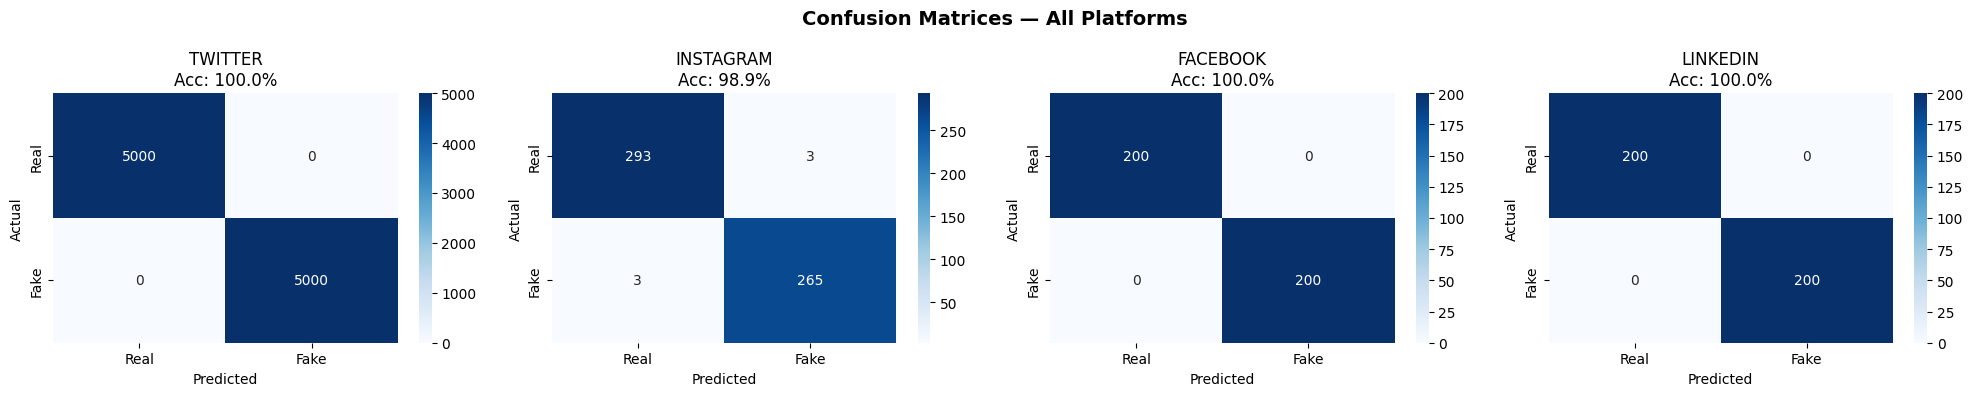

Confusion matrices saved!


In [14]:
# Confusion Matrix for each platform
n_platforms = len(results)
fig, axes   = plt.subplots(1, n_platforms, figsize=(5 * n_platforms, 4))
if n_platforms == 1:
    axes = [axes]

for ax, (platform, r) in zip(axes, results.items()):
    cm = confusion_matrix(r['y_test'], r['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Real', 'Fake'],
                yticklabels=['Real', 'Fake'])
    ax.set_title(f'{platform.upper()}\nAcc: {r["accuracy"]:.1f}%')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All Platforms', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('dataset/confusion_matrices.png', dpi=150)
plt.show()
print('Confusion matrices saved!')

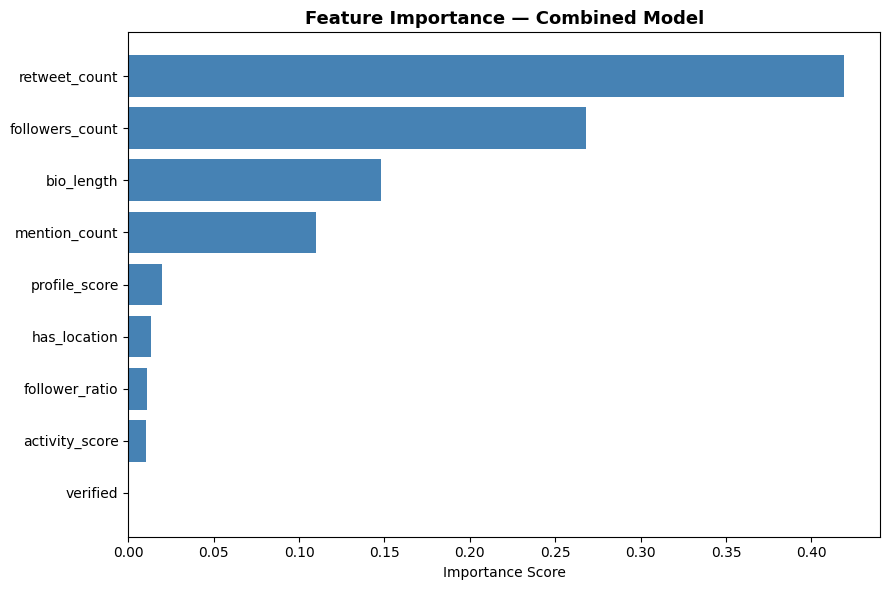

Feature Importance Ranking:
        Feature  Importance
  retweet_count    0.419234
followers_count    0.267995
     bio_length    0.147918
  mention_count    0.109917
  profile_score    0.019847
   has_location    0.013226
 follower_ratio    0.011033
 activity_score    0.010462
       verified    0.000369


In [15]:
# Feature Importance Chart (Combined Model)
importances = model_combined.feature_importances_
feat_df     = pd.DataFrame({'Feature': features, 'Importance': importances})
feat_df     = feat_df.sort_values('Importance', ascending=True)

plt.figure(figsize=(9, 6))
plt.barh(feat_df['Feature'], feat_df['Importance'], color='steelblue')
plt.xlabel('Importance Score')
plt.title('Feature Importance — Combined Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('dataset/feature_importance.png', dpi=150)
plt.show()

print('Feature Importance Ranking:')
print(feat_df.sort_values('Importance', ascending=False).to_string(index=False))

---
## Step 9: Predict on New / Custom Data
Type in any account's details and see if the model thinks it is FAKE or REAL

In [16]:
# Load the saved combined model
loaded_model    = joblib.load('model/model.pkl')
loaded_scaler   = joblib.load('model/scaler.pkl')
loaded_features = joblib.load('model/features.pkl')

# ============================================================
# CHANGE THESE VALUES to test any account you want!
# ============================================================
new_account = {
    'followers_count': 50,     # number of followers
    'verified':        0,      # 1 = verified, 0 = not verified
    'retweet_count':   5,      # number of retweets
    'mention_count':   3,      # number of mentions
    'bio_length':      10,     # length of bio in characters
    'has_location':    0,      # 1 = has location, 0 = no location
}
# ============================================================

# Auto-compute engineered features
new_account['follower_ratio'] = new_account['followers_count'] / (new_account['mention_count'] + 1)
new_account['activity_score'] = new_account['retweet_count']   / (new_account['followers_count'] + 1)
new_account['profile_score']  = new_account['verified'] + new_account['has_location'] + int(new_account['bio_length'] > 0)

input_df      = pd.DataFrame([new_account])[loaded_features]
input_scaled  = loaded_scaler.transform(input_df)
prediction    = loaded_model.predict(input_scaled)[0]
probability   = loaded_model.predict_proba(input_scaled)[0]

print('=' * 40)
print('  PREDICTION RESULT')
print('=' * 40)
print(f'  Account type : {"FAKE ACCOUNT" if prediction == 1 else "REAL ACCOUNT"}')
print(f'  Confidence   : {max(probability)*100:.1f}%')
print(f'  Real prob    : {probability[0]*100:.1f}%')
print(f'  Fake prob    : {probability[1]*100:.1f}%')
print('=' * 40)

  PREDICTION RESULT
  Account type : FAKE ACCOUNT
  Confidence   : 100.0%
  Real prob    : 0.0%
  Fake prob    : 100.0%


In [17]:
# Batch Prediction — test multiple accounts at once

test_accounts = pd.DataFrame([
    # followers, verified, retweets, mentions, bio_len, location
    {'followers_count': 45000, 'verified': 1, 'retweet_count': 3000, 'mention_count': 1500, 'bio_length': 250, 'has_location': 1},
    {'followers_count': 12,    'verified': 0, 'retweet_count': 2,    'mention_count': 1,    'bio_length': 5,   'has_location': 0},
    {'followers_count': 5000,  'verified': 0, 'retweet_count': 500,  'mention_count': 200,  'bio_length': 180, 'has_location': 1},
    {'followers_count': 80,    'verified': 0, 'retweet_count': 10,   'mention_count': 5,    'bio_length': 15,  'has_location': 0},
    {'followers_count': 1200,  'verified': 1, 'retweet_count': 800,  'mention_count': 400,  'bio_length': 120, 'has_location': 1},
])

# Compute engineered features
test_accounts['follower_ratio'] = test_accounts['followers_count'] / (test_accounts['mention_count'] + 1)
test_accounts['activity_score'] = test_accounts['retweet_count']   / (test_accounts['followers_count'] + 1)
test_accounts['profile_score']  = test_accounts['verified'] + test_accounts['has_location'] + (test_accounts['bio_length'] > 0).astype(int)

X_new    = loaded_scaler.transform(test_accounts[loaded_features])
preds    = loaded_model.predict(X_new)
probs    = loaded_model.predict_proba(X_new)

test_accounts['Prediction']  = ['FAKE' if p == 1 else 'REAL' for p in preds]
test_accounts['Fake_Prob_%'] = (probs[:, 1] * 100).round(1)

print('=== BATCH PREDICTION RESULTS ===')
print(test_accounts[['followers_count', 'verified', 'bio_length', 'has_location', 'Prediction', 'Fake_Prob_%']].to_string(index=False))

=== BATCH PREDICTION RESULTS ===
 followers_count  verified  bio_length  has_location Prediction  Fake_Prob_%
           45000         1         250             1       REAL          0.0
              12         0           5             0       FAKE        100.0
            5000         0         180             1       REAL          0.0
              80         0          15             0       FAKE        100.0
            1200         1         120             1       REAL          0.0


---
## Project Complete!

| Step | What was done |
|------|---------------|
| 1 | Libraries installed and imported |
| 2 | Twitter dataset generated (50,000 accounts) |
| 3 | Facebook and LinkedIn datasets generated |
| 4 | All platforms preprocessed and merged |
| 5 | EDA charts and correlation heatmap created |
| 6 | Feature engineering (3 new features added) |
| 7 | Random Forest trained for each platform + combined |
| 8 | Confusion matrix and feature importance visualized |
| 9 | Prediction on single and batch new accounts |

### Saved Files:
- `dataset/combined_data.csv` — Full cleaned dataset
- `model/model.pkl` — Combined prediction model
- `model/scaler.pkl` — Data scaler
- `model/twitter_model.pkl`, `model/facebook_model.pkl`, `model/linkedin_model.pkl`
- `dataset/eda_analysis.png`, `dataset/confusion_matrices.png`, `dataset/feature_importance.png`

---
**Shah Khalid and Ziad Muhammad | Final Year Project**